# Predicting Airline Recommendation from Customer Reviews
## **An End-to-End NLP Pipeline for Text Classification**

### - **Module:** M508 Big Data Analytics
### - **Name:** Varsha Babu
### - **GH No.:** GH1048862

## 1. Problem Statement

### Business Problem
Airlines collect huge volumes of customer reviews, but going through them one 
by one to identify satisfied and dissatisfied customers is not realistic at 
scale. What airlines need is a way to automatically identify reviews that 
signal an unhappy customer, so the right team can intervene before that 
frustration turns into a lost customer or a public complaint.

### Why This Matters
If an airline can flag negative sentiment automatically, it opens up a few 
practical benefits:
- Customers who probably won't recommend the airline again can be identified 
  and followed up with
- Recurring negative themes in the language of the reviews can be surfaced 
  and investigated further by the customer-experience team
- Staff spend less time manually sorting through reviews and more time acting 
  on the ones that matter

### Data Collection
For this project I'm using the **Airline Reviews** dataset (Bhojani, 2023), 
which was scraped from AirlineQuality.com and is available on
Kaggle: https://www.kaggle.com/datasets/juhibhojani/airline-reviews  
It has around 23,000 reviews, along with route and aircraft details and a 
"Recommended" column (Yes/No) that we can use as our label.

### Framing This as an NLP Task
This comes down to a **binary text classification** problem: given the text 
of a review, predict whether that customer would recommend the airline. The 
review text is the input, and the existing "Recommended" column gives us the 
ground truth to train and test against.

## 2. High-Level System Design

Before jumping into the code, it helps to lay out what this pipeline actually 
looks like end to end, and why each piece is there.

**Overall flow:**

Raw Reviews -> Text Cleaning & Preprocessing -> Feature Representation (TF-IDF) 
-> Classification Model(s) -> Evaluation -> Business Insights

**Why these components:**

- **Text Cleaning & Preprocessing** - Reviews are written informally, so 
  they need to be standardised (lowercasing, removing punctuation/stopwords, 
  lemmatising) to make the text suitable for machine-learning processing.
  
- **Feature Representation** - Machine learning models can't work with raw 
  text, so the cleaned reviews are converted into numerical vectors using 
  TF-IDF, which captures which words matter most in each review relative to 
  the whole dataset.

  
- **Classification Models** - Two models are trained and compared on the same 
  features, so the results can be judged against each other rather than in 
  isolation.

  
- **Evaluation** - Accuracy alone isn't enough for this kind of problem, so precision, recall, F1, a confusion matrix, and a review of specific misclassified examples are used to understand what kind of mistakes each model makes and why.
  
- **Business Insights** - The final step ties the technical results back to 
  what actually matters for the airline: which model to trust, and what to 
  do with its predictions.

Each of these stages is covered in more detail in the sections that follow.

## 3. Data Loading & Exploration

### Why This Dataset
I chose the Airline Reviews dataset because it's a good match for the 
problem above - it's real customer feedback, not synthetic or templated 
text, and it already comes with a "Recommended" label, so I don't need to 
manually annotate anything or guess at ground truth. It's also a decent 
size (~23,000 rows), which gives enough data to train and properly test a 
classifier without needing heavy augmentation.

Before doing any preprocessing, I want to get a feel for the data: how big 
it is, what the class balance looks like, and whether there's anything 
messy (missing values, duplicate reviews, etc.) that needs handling early.

In [1]:
import pandas as pd

df = pd.read_csv("Airline_review.csv")

print(df.shape)
df.head(3)

(23171, 20)


,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended
0,0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,4.0,NaN,NaN,3.0,yes
1,1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,1.0,NaN,NaN,2.0,no
2,2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,1.0,NaN,NaN,2.0,no


In [2]:
print(df['Recommended'].value_counts(normalize=True))
print(df.isnull().sum().sort_values(ascending=False).head(10))

Recommended
no     0.66307
yes    0.33693
Name: proportion, dtype: float64
Wifi & Connectivity       17251
Aircraft                  16042
Inflight Entertainment    12342
Food & Beverages           8671
Ground Service             4793
Cabin Staff Service        4260
Seat Comfort               4155
Route                      3828
Date Flown                 3754
Type Of Traveller          3738
dtype: int64


The dataset shows a moderate class imbalance: about 66% of reviews are 
"no" (not recommended) and 34% are "yes". This isn't extreme, but it's 
enough that accuracy alone would be a misleading metric - a model could 
score ~66% just by always predicting "no". This means precision, recall, 
and F1 (especially for the minority "yes" class) will matter more than 
raw accuracy when evaluating the models later.

Missing values are concentrated in the secondary rating columns (Wifi & 
Connectivity, Aircraft, Inflight Entertainment, Food & Beverages, etc.), 
which makes sense - not every flight has these amenities, or reviewers 
simply skip rating them. Since this project relies on the review text and 
the "Recommended" label as the core inputs, these missing values don't 
directly affect the pipeline. They would only matter if we later chose to 
incorporate these ratings as additional features.

In [3]:
print(df[['Review', 'Recommended']].isnull().sum())
df['review_length'] = df['Review'].astype(str).apply(lambda x: len(x.split()))
print(df['review_length'].describe())

Review         0
Recommended    0
dtype: int64
count    23171.000000
mean       130.635493
std         99.045386
min          2.000000
25%         64.000000
50%        101.000000
75%        164.500000
max        804.000000
Name: review_length, dtype: float64


No missing values in `Review` or `Recommended`, so the full dataset is usable. 
Reviews average ~131 words (median 101), ranging from very short (2 words) to 
quite long (804 words) - long enough for meaningful text features, so no 
minimum-length filtering is needed.

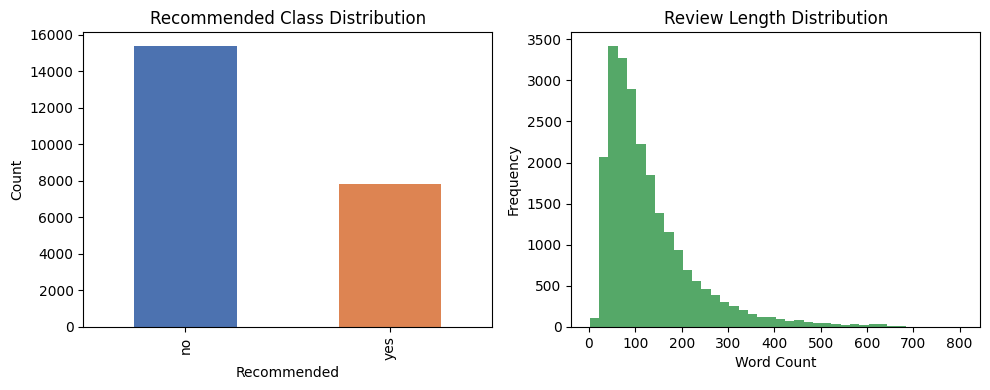

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df['Recommended'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Recommended Class Distribution')
axes[0].set_xlabel('Recommended')
axes[0].set_ylabel('Count')

df['review_length'].plot(kind='hist', bins=40, ax=axes[1], color='#55A868')
axes[1].set_title('Review Length Distribution')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.show()

The bar chart confirms the class imbalance visually, and the histogram shows most reviews cluster in the 50-150 word range with a long right tail of longer reviews.

## 4. Text Cleaning & Preprocessing

Reviews are written casually, with punctuation, capitalisation, and stopwords 
that may add noise for a model trying to learn recommendation patterns. I'll 
lowercase the text, strip punctuation, remove stopwords, and lemmatise using 
spaCy - lemmatisation over stemming since it produces real, valid words, 
which keeps the vocabulary cleaner for TF-IDF later.

In [5]:
import spacy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def clean_batch(texts):
    docs = nlp.pipe(texts, batch_size=100)
    return [" ".join([t.lemma_ for t in doc if t.is_alpha and not t.is_stop]) for doc in docs]

df['clean_review'] = clean_batch(df['Review'].astype(str).str.lower())
df[['Review', 'clean_review']].head(2)

,Review,clean_review
0,Moroni to Moheli. Turned out to be a pretty ...,moroni moheli turn pretty decent airline onlin...
1,Moroni to Anjouan. It is a very small airline...,moroni anjouan small airline ticket advise tur...


The cleaned output shows the pipeline working as intended: punctuation and stopwords are removed, and words are reduced to their lemma form (e.g. “turned” -> “turn”, “advised” -> “advise”), leaving a content-focused version of each review ready for feature extraction.


## 5. Feature Engineering / Text Representation

To turn the cleaned text into numerical features that a model can use, I will apply TF-IDF. A maximum of 5,000 features was used to keep the vocabulary large enough to capture meaningful words while limiting dimensionality and training time, since most of the discriminative signal in review text tends to come from a relatively small set of frequent, sentiment-bearing words.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'], df['Recommended'], test_size=0.2, random_state=42, stratify=df['Recommended']
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape, X_test_tfidf.shape)

(18536, 5000) (4635, 5000)


In [7]:
feature_names = tfidf.get_feature_names_out()
bigrams = [f for f in feature_names if ' ' in f]
print(f"Number of bigrams in top 5000 features: {len(bigrams)}")
print("Sample bigrams:", bigrams[:20])

Number of bigrams in top 5000 features: 2291
Sample bigrams: ['able board', 'able check', 'able flight', 'able fly', 'able use', 'absolute bad', 'absolutely bad', 'absolutely horrible', 'absolutely terrible', 'abu dhabi', 'actual flight', 'add insult', 'additional cost', 'additional fee', 'aer lingus', 'aerolineas argentina', 'afternoon flight', 'agent say', 'agent tell', 'ahead schedule']


The data was split into 18,536 training reviews and 4,635 test reviews using a stratified 80/20 split. TF-IDF was fitted only on the training data and then applied to the test data, preventing information from the test set from influencing feature construction. The resulting representation contains 5,000 features for each review, providing a manageable and consistent input for the classification models.

Only the review text was used as the model's input. The numeric sub-ratings available in the dataset (e.g. Seat Comfort, Cabin Staff Service, Value For Money) were deliberately excluded, since they are strongly correlated with the `Recommended` label and including them would let the model rely on those scores rather than genuinely learning from the language of the review - this would turn the task into a trivial numeric-threshold problem rather than a text classification one.

## 6. Modelling

I'm comparing two models on the same TF-IDF features: Logistic Regression, which provides interpretable coefficients that can be linked back to specific words, and Linear SVM, which is well suited to high-dimensional sparse data such as TF-IDF vectors and often performs strongly on text classification tasks. Both are computationally lightweight compared with transformer-based models, making them appropriate for this project's scope. Comparing both lets me judge whether the added complexity of SVM is actually worth it here.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

lr_preds = lr.predict(X_test_tfidf)
svm_preds = svm.predict(X_test_tfidf)

To move beyond default hyperparameters, Logistic Regression's regularization 
strength (C) was tuned using 5-fold cross-validation on the training set, 
optimising for F1-macro to account for class imbalance. This also validates 
that the 90% test accuracy isn't an artefact of a single lucky train-test split.

In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid.fit(X_train_tfidf, y_train)

print("Best C:", grid.best_params_)
print("Best CV F1-macro score:", grid.best_score_)

lr = grid.best_estimator_
lr_preds = lr.predict(X_test_tfidf)

Best C: {'C': 1}
Best CV F1-macro score: 0.8861233570180111


The cross-validated search confirms that the default regularization strength 
(C=1) was already optimal, with a mean F1-macro of 0.886 across 5 folds - 
consistent with the test-set performance reported later. This indicates the 
model's performance is stable and not an artefact of a single train-test split.

## 7. Evaluation & Critical Analysis

Before looking at error metrics, it's worth checking whether the model 
learned sensible signal - do the most influential words actually make 
intuitive sense for each class?

In [10]:
import numpy as np
feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr.coef_[0]
print("Top 'yes' words:", feature_names[np.argsort(coefs)[-10:]])
print("Top 'no' words:", feature_names[np.argsort(coefs)[:10]])

Top 'yes' words: ['professional' 'friendly' 'easy' 'nice' 'comfortable' 'smooth'
 'excellent' 'great' 'thank' 'good']
Top 'no' words: ['bad' 'rude' 'poor' 'pay' 'tell' 'terrible' 'cancel' 'avoid' 'hour'
 'uncomfortable']


The most influential words are broadly consistent with the predicted 
classes. Words such as "excellent", "friendly", and "comfortable" are 
associated with `yes`, while terms such as "rude", "terrible", and "cancel" 
are associated with `no`. This suggests that the model is capturing 
meaningful patterns in the review text that are relevant to customer 
recommendation behaviour.

Since the classes are imbalanced (66% no / 34% yes), accuracy alone isn't 
enough - I'll look at precision, recall, and F1 per class, plus a confusion matrix and a set of actual misclassified reviews, to see what kind of mistakes each model makes and which is more reliable for this business problem.

Logistic Regression
              precision    recall  f1-score   support

          no       0.92      0.93      0.92      3073
         yes       0.87      0.83      0.85      1562

    accuracy                           0.90      4635
   macro avg       0.89      0.88      0.89      4635
weighted avg       0.90      0.90      0.90      4635

Linear SVM
              precision    recall  f1-score   support

          no       0.91      0.93      0.92      3073
         yes       0.86      0.83      0.84      1562

    accuracy                           0.90      4635
   macro avg       0.89      0.88      0.88      4635
weighted avg       0.90      0.90      0.90      4635



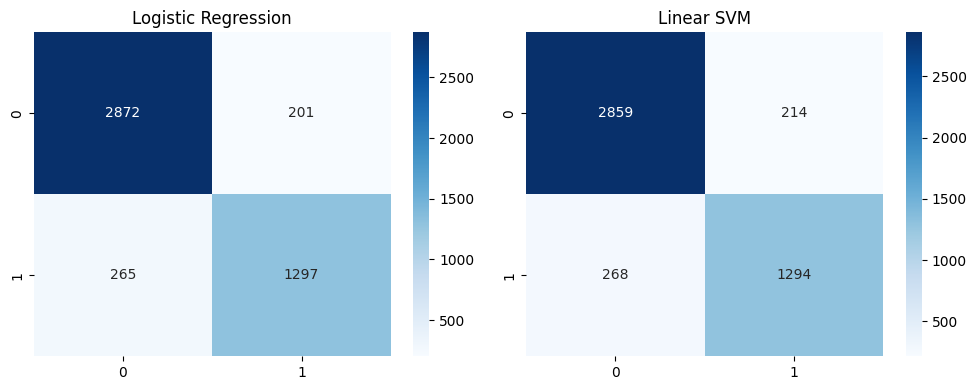

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Logistic Regression")
print(classification_report(y_test, lr_preds))

print("Linear SVM")
print(classification_report(y_test, svm_preds))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')

sns.heatmap(confusion_matrix(y_test, svm_preds), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Linear SVM')

plt.tight_layout()
plt.show()

Adding bigrams (ngram_range=(1,2)) had negligible effect on performance - 
accuracy remained at 90% and the `yes` F1-score moved only marginally (0.84 
to 0.85). Inspecting the 2,291 bigrams that entered the feature set (Section 
5) confirmed why: none of them capture negation patterns such as "not good," 
because negation words ("not", "no", "never") are removed during stopword 
filtering in Section 4, before TF-IDF ever sees the text. This means bigrams 
cannot recover information that preprocessing has already discarded - a fix 
would need to happen upstream, by preserving negation words during cleaning 
rather than changing the feature representation. This is left as a direction 
for future improvement given the scope of this project.

To understand what kinds of reviews the model gets wrong, it is useful to examine a few actual misclassified examples rather than relying only on aggregate evaluation metrics.

In [12]:
results = pd.DataFrame({
    'review': df.loc[X_test.index, 'Review'].values,
    'actual': y_test.values,
    'predicted': lr_preds
})

false_positives = results[
    (results['actual'] == 'no') & (results['predicted'] == 'yes')
]

false_negatives = results[
    (results['actual'] == 'yes') & (results['predicted'] == 'no')
]

print("False Positives (actual: no, predicted: yes)")
for r in false_positives['review'].head(3):
    print("-", r[:250], "\n")

print("False Negatives (actual: yes, predicted: no)")
for r in false_negatives['review'].head(3):
    print("-", r[:250], "\n")

False Positives (actual: no, predicted: yes)
-   The trip was okay and the flight on time. They need to service food or at least soda or water in the plane. The seats are not comfortable. 

- Moscow (DME) to Baku and it was a great flight. The plane was newer than many I've been on in the US and very clean and comfortable. The service was good even in economy class and food was generous and quite tasty. The next flight Baku to Tblisi was  

-   
The aircraft were well maintained and new. The crew on the Tbilisi to Bahrain flight were very courteous and professional - the service was excellent and the vegetarian meal was very good. There was a delay of 50 minutes to the flight (not the fa 

False Negatives (actual: yes, predicted: no)
-   I must say that Copa Airline's customer service by phone is amazing. I'm travelling in December 2022 and had a few problems with my itinerary (cancellation, changes, etc). I initially bought my tickets through Expedia, but they had wrong informatio 

-

The false positives are largely reviews that are mostly positive in tone but 
contain a smaller negative segment (e.g. a delay or an issue with a later leg 
of the journey) - since TF-IDF weighs word frequency across the whole review, 
a short negative section can be outweighed by a longer positive one. The false 
negatives show the opposite problem: reviews that mention negative-sounding 
words (e.g. "cancellation", "problems") while describing an issue that was 
ultimately resolved well, which the model cannot distinguish from an actual 
complaint. This suggests the model's main weakness is not sarcasm as such, but 
its inability to track how sentiment develops or resolves across a review, 
since it has no sense of word order or context.

Both models perform almost identically, with 90% accuracy and near-matching precision, recall, and F1-scores across both classes. Logistic Regression has a slight edge in `yes` precision (0.87 vs 0.86), while SVM correctly identifies marginally more `yes` cases (1,293 vs 1,289). In practice, these differences are negligible.

Because the business objective is to identify customers who do not 
recommend the airline, the `no` class is operationally the most important 
class. With that in mind, the more important errors are the 200–214 cases 
where reviews that were actually `no` were predicted as `yes`. These 
represent non-recommending customers who could be missed by the system and 
therefore not flagged for follow-up. Given the near-identical performance, 
Logistic Regression was selected because its performance was nearly identical to Linear SVM while providing directly interpretable coefficients that can be linked to individual words.

## 8. Final Discussion & Business Recommendations

### Strengths

The pipeline is simple, interpretable, and performs well, achieving 90% accuracy with an F1-score of 0.92 for the `no` class and 0.84 for the `yes` class. The top TF-IDF/coefficient words (e.g. "excellent", "friendly" vs. "rude", "cancel") also align with intuitive sentiment, indicating that the model is capturing meaningful patterns in the review text. Using TF-IDF with a linear classifier keeps the approach lightweight compared to deep-learning alternatives, which fits the scope of this project.

### Limitations

- **No sense of word order or context.** TF-IDF treats a review as a bag of words, so it cannot tell which part reflects the reviewer's overall conclusion versus a smaller side comment.

- **Cannot track how sentiment develops within a review.** The error analysis in Section 7 shows this directly: the false-positive examples included mixed-sentiment reviews as well as reviews that appeared largely positive despite having a `no` label, while false negatives included negative-sounding words such as "cancellation" and "problems" in reviews that were ultimately positive.

- **Negation can be lost during preprocessing.** The stopword removal step drops words like "not" and "no", and contractions such as "n't" are stripped out too — so an expression like "not good" can end up represented mainly by the word "good."

- **Class imbalance means accuracy alone isn't a reliable measure.** This was addressed through precision, recall and F1-score rather than resampling, but a resampling approach was not explored.

### Business Implications

A 90% accurate classifier could meaningfully reduce the manual effort needed to sort through customer feedback. However, because the business priority is catching dissatisfied customers, the more consequential errors are the roughly 200–214 cases where an actual `no` review was predicted as `yes` — these represent unhappy customers the system would miss entirely. Given this, the model should support human review rather than replace it outright, especially in its current form.

### Recommendations

- **Use the classifier as a customer-feedback triage tool.** The airline can use the model to automatically identify reviews that indicate customers are unlikely to recommend the airline, reducing the amount of feedback that staff need to manually screen.

- **Reduce missed dissatisfied customers through confidence-based review and threshold tuning.** Because false positives (actual `no` reviews predicted as `yes`) are the errors that let dissatisfied customers slip through, the airline could use prediction confidence in a future deployment to flag `yes` predictions closer to the decision boundary for spot-checking, and/or adjust the classification threshold to increase recall for the `no` class if missing dissatisfied customers is considered more costly than generating additional alerts.

- **Use identified negative feedback to target service improvements.** Customer-experience teams can analyse the flagged reviews to identify recurring issues such as delays, customer service, food, seating and other service problems. These insights can then inform operational improvements.

- **Improve the NLP system before wider rollout.** The airline could preserve important negation words during preprocessing as a low-cost improvement. For a later development stage, a context-aware model such as BERT could be evaluated to better capture negation, word order and contextual relationships.

### Conclusion

This project developed an end-to-end NLP pipeline for predicting airline customer recommendations from review text. The results show that TF-IDF combined with linear classification can achieve strong performance, with around 90% accuracy and good F1-scores across both classes. The error analysis also showed that the models can struggle with mixed sentiment, contextual language and negation.

Overall, the pipeline demonstrates that customer reviews can be automatically analysed to support airline feedback management. However, the model should be used as a decision-support tool alongside human review. Future improvements could focus on preserving negation during preprocessing and evaluating more context-aware NLP methods.

## References

Bhojani, J. (2023) *Airline Reviews*. Kaggle. Available at: https://www.kaggle.com/datasets/juhibhojani/airline-reviews (Accessed: 1 September 2026).

Honnibal, M. and Montani, I. (2017) *spaCy 2: Natural Language Understanding with Bloom Embeddings, Convolutional Neural Networks and Incremental Parsing*. Explosion AI.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M. and Duchesnay, E. (2011) 'Scikit-learn: Machine Learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825–2830.